# Leer `panel_caso_mes.csv`

Panel caso × mes de los reportes mensuales de la Defensoría (extractor local).

Una fila = un conflicto en un mes. Minería: filtrar `es_socioambiental == 1` y/o `menciona_mineria == 1`.

In [1]:
from pathlib import Path
import sys

import pandas as pd

# Si el kernel arranca en la raíz del proyecto o en 02_codigo:
CODIGO = Path.cwd() if (Path.cwd() / "rutas.py").exists() else Path.cwd() / "02_codigo"
sys.path.insert(0, str(CODIGO))

from rutas import CASOS_UNICOS_CSV, ENCODING_CSV, PROCESADOS, ruta_panel

PANEL_CSV = ruta_panel()
print("Panel:", PANEL_CSV)
print("Existe:", PANEL_CSV.exists())

Panel: C:\Users\USER\OneDrive\Escritorio\2026-2\Asistente\01_datos\procesados\conflictos\panel_caso_mes.csv
Existe: True


## Cargar el panel

Todo como texto al leer; las banderas y el número de reporte se convierten después.

In [2]:
panel = pd.read_csv(PANEL_CSV, dtype=str, encoding=ENCODING_CSV, keep_default_na=False)

for col in ("numero_reporte", "anio", "mes", "pagina", "caso_id",
            "es_socioambiental", "menciona_mineria"):
    if col in panel.columns:
        panel[col] = pd.to_numeric(panel[col], errors="coerce")

print(f"Filas: {len(panel):,}")
print(f"Columnas ({len(panel.columns)}): {list(panel.columns)}")
panel.head(3)

Filas: 35,176
Columnas (23): ['caso_id', 'numero_reporte', 'anio', 'mes', 'estado', 'departamento', 'tipo', 'caso', 'ubicacion', 'actores_primarios', 'actores_secundarios', 'actores_terciarios', 'actores', 'ingreso_como', 'codigo', 'hechos_del_mes', 'es_socioambiental', 'menciona_mineria', 'formato', 'archivo', 'pagina', 'caso_estandarizado', 'texto_crudo']


,caso_id,numero_reporte,anio,mes,estado,departamento,tipo,caso,ubicacion,actores_primarios,...,ingreso_como,codigo,hechos_del_mes,es_socioambiental,menciona_mineria,formato,archivo,pagina,caso_estandarizado,texto_crudo
0,545,1,2004,4,Activo,Ayacucho,,"el alcalde, procedente del anexo de Porta Cruz...",Carapo,,...,,,,0,0,lista_narrativa_2004,abril 2004 - Reporte 01 - Conflictos sociales.pdf,NaN,alcalde procedente anexo porta cruz habria des...,"1. Autoridad: Alcalde distrital de Carapo, pro..."
1,546,1,2004,4,Activo,Ayacucho,,El Frente de Defensa ha cuestionado al alcalde...,Cangallo,,...,,,,0,0,lista_narrativa_2004,abril 2004 - Reporte 01 - Conflictos sociales.pdf,NaN,frente defensa ha cuestionado alcalde porque s...,"2. Autoridad: Alcalde provincial de Cangallo, ..."
2,1,1,2004,4,Activo,Amazonas,,el alcalde fue denunciado por el delito contra...,Huancas,,...,,,,0,0,lista_narrativa_2004,abril 2004 - Reporte 01 - Conflictos sociales.pdf,NaN,alcalde fue denunciado delito contra derecho s...,"3. Autoridad: Alcalde Distrital de Huancas, pr..."


## Resumen rápido

In [3]:
print("Casos únicos (caso_id):", panel["caso_id"].nunique())
print("Reportes distintos:", panel["numero_reporte"].nunique())
print("Años:", int(panel["anio"].min()), "–", int(panel["anio"].max()))
print("Socioambientales:", int((panel["es_socioambiental"] == 1).sum()))
print("Mencionan minería:", int((panel["menciona_mineria"] == 1).sum()))
print()
print("Por estado:")
print(panel["estado"].value_counts().to_string())
print()
print("Por formato:")
print(panel["formato"].value_counts().to_string())

Casos únicos (caso_id): 4069
Reportes distintos: 269
Años: 2004 – 2026
Socioambientales: 20104
Mencionan minería: 20234

Por estado:
estado
Activo      32557
Latente      2206
Resuelto      400
Nuevo          13

Por formato:
formato
adjuntia_portada_estadistica    26300
infografia_ciclo_2024            2893
reporte_n_tabla_regiones         2593
unidad_reporte_n                 1735
unidad_sumilla                   1608
lista_narrativa_2004               47


## Filtrar minería / socioambiental

El universo queda intacto; el recorte es una vista.

In [4]:
mineria = panel[
    (panel["es_socioambiental"] == 1) | (panel["menciona_mineria"] == 1)
].copy()

print(f"Filas minería/socioambiental: {len(mineria):,}")
print(f"Casos únicos en ese filtro: {mineria['caso_id'].nunique():,}")
mineria[["caso_id", "anio", "mes", "departamento", "estado", "tipo", "caso"]].head(10)

Filas minería/socioambiental: 23,006
Casos únicos en ese filtro: 2,253


,caso_id,anio,mes,departamento,estado,tipo,caso
11,708,2004,4,Cajamarca,Activo,,existe descontento de un sector de la població...
19,1289,2004,4,Ica,Activo,,pugnas y enfrentamientos entre los alcades dis...
31,2848,2004,4,Piura,Activo,,Consideran que el alcalde está colaborando con...
68,1611,2004,5,La Libertad,Activo,,"Caserío de Nueva Arenita, distrito de Paiján, ..."
76,2850,2004,5,Piura,Activo,,"Carmen de la Frontera, Provincia de Huancabamb..."
110,550,2004,6,Ayacucho,Activo,,Pugnas y enfrentamientos entre los Alcaldes Di...
115,1617,2004,6,La Libertad,Activo,,Descontento de la población generado al entera...
125,2851,2004,6,Piura,Activo,,"Desde el mes de abril de 2004, ronderos de Car..."
143,1618,2004,6,La Libertad,Resuelto,,"En abril de 2004, la población del caserío tom..."
149,1619,2004,6,La Libertad,Nuevo,,"El 13 de junio, el Alcalde, presuntamente pres..."


## Serie mensual (conteo de fichas)

In [5]:
serie = (
    panel.groupby(["anio", "mes"], as_index=False)
    .size()
    .rename(columns={"size": "n_fichas"})
    .sort_values(["anio", "mes"])
)
serie["periodo"] = (
    serie["anio"].astype(int).astype(str)
    + "-"
    + serie["mes"].astype(int).astype(str).str.zfill(2)
)
serie.tail(12)

,anio,mes,n_fichas,periodo
255,2025,8,67,2025-08
256,2025,9,73,2025-09
257,2025,10,84,2025-10
258,2025,11,79,2025-11
259,2025,12,74,2025-12
260,2026,1,79,2026-01
261,2026,2,78,2026-02
262,2026,3,59,2026-03
263,2026,4,61,2026-04
264,2026,5,56,2026-05


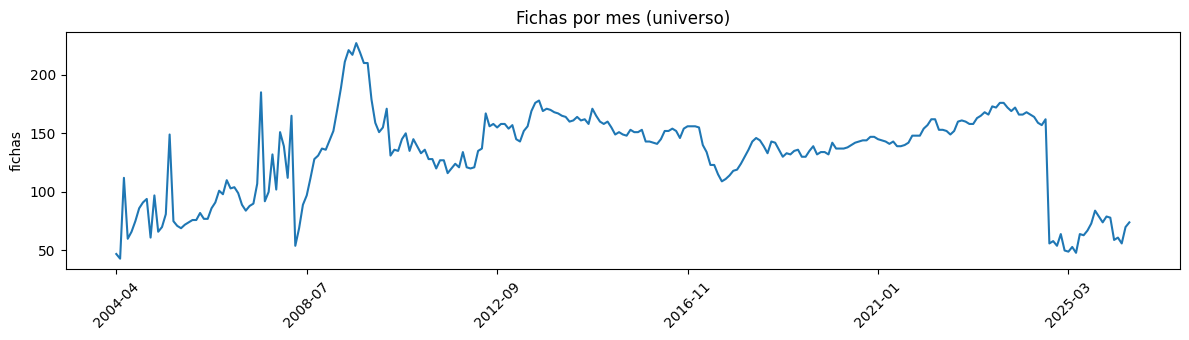

In [6]:
ax = serie.set_index("periodo")["n_fichas"].plot(
    figsize=(12, 3.5), title="Fichas por mes (universo)", xlabel="", ylabel="fichas"
)
ax.tick_params(axis="x", labelrotation=45)
ax.figure.tight_layout()

## Un caso a lo largo del tiempo

Cambia `CASO_ID` por el id que quieras inspeccionar.

In [10]:
CASO_ID = int(panel["caso_id"].dropna().iloc[-1])

trayectoria = (
    panel[panel["caso_id"] == CASO_ID]
    .sort_values(["anio", "mes", "numero_reporte"])
)
print(f"caso_id={CASO_ID} → {len(trayectoria)} filas")
trayectoria[
    ["numero_reporte", "anio", "mes", "estado", "departamento", "tipo", "caso", "hechos_del_mes"]
]


caso_id=517 → 1 filas


,numero_reporte,anio,mes,estado,departamento,tipo,caso,hechos_del_mes
35175,269,2026,7,Latente,Arequipa,Sociambiental Provincia de 9. Integrantes de l...,Jimbe-Contaminación (Áncash) - - - 7 7 - Fuent...,"El caso no presenta nuevos hechos, ni particip..."


## Casos únicos (opcional)

Una fila por `caso_id`, con `n_meses` y banderas a lo largo del tiempo.

In [11]:
if CASOS_UNICOS_CSV.exists():
    unicos = pd.read_csv(CASOS_UNICOS_CSV, dtype=str, encoding=ENCODING_CSV, keep_default_na=False)
    unicos["n_meses"] = pd.to_numeric(unicos["n_meses"], errors="coerce")
    unicos["es_socioambiental"] = pd.to_numeric(unicos["es_socioambiental"], errors="coerce")
    unicos["menciona_mineria"] = pd.to_numeric(unicos["menciona_mineria"], errors="coerce")
    print(f"Casos únicos: {len(unicos):,}")
    display(unicos.sort_values("n_meses", ascending=False).head(10))
else:
    print("No está casos_unicos.csv en", CASOS_UNICOS_CSV)

Casos únicos: 4,069


,caso_id,caso,departamento,tipo,n_meses,es_socioambiental,menciona_mineria,resumen_llm,empresa,mineral,comunidades,demanda_principal,tipo_normalizado,confianza,texto_ilegible
3332,1001,Pobladores de la provincia de Espinar exigen a...,Cusco,Socioambiental,130,1,1,Pobladores de la provincia de Espinar exigen a...,Antapaccay S.A.,metales pesados,Huisa; Alto Huancané; Espinar; Pallpata,Exigen el cumplimiento de los acuerdos de la m...,socioambiental,alta,0
3414,3223,Pobladores del distrito de Llalli expresan su ...,Puno,Socioambiental,122,1,1,"Pobladores de los distritos de Llalli, Cupi, U...",Aruntani S.A.C.,metales,Llalli; Cupi; Umachiri; Ayaviri; Ocuviri,Los pobladores expresan su preocupación por la...,socioambiental,alta,0
3240,3866,Las organizaciones usuarios de agua del Caserí...,Áncash,Socioambiental,118,1,1,Las organizaciones de usuarios de agua de los ...,Empresa Minera Barrick Misquichilca S.A. (MBM),,Caseríos Atupa; Caseríos Antahurán; distrito d...,Reclaman la devolución del manantial Yarcok y ...,socioambiental,alta,0
2907,3178,La población de Juliaca demandó al Gobierno Re...,Puno,Asuntos de gobierno regional,118,0,0,La población de Juliaca demandó al Gobierno Re...,,,Juliaca; La Capilla; Zarumilla; Cerro Colorado,La población de Juliaca demanda la construcció...,gobierno_local,alta,0
3361,2829,Pobladores del distrito de Simón Bolívar deman...,Pasco,Socioambiental,116,1,1,Pobladores del distrito de Simón Bolívar deman...,Activos Mineros S.A.C. (AMSAC); Volcan Compañí...,metales pesados,Comunidad campesina de Quiulacocha; comunidad ...,Los pobladores demandan la resolución de probl...,socioambiental,alta,0
3406,3221,Los pobladores del distrito de Ocuviri provinc...,Puno,Socioambiental,115,1,1,"Los pobladores del distrito de Ocuviri, provin...",Arasi S.A.C.; Aruntani S.A.C.,,Hatun Ayllu; Caycho; Cerro minas; Ocuviri,Los pobladores exigen un espacio de diálogo pa...,socioambiental,alta,0
2096,827,Pobladores de Hualgayoc demanda el cumplimient...,Cajamarca,Socioambiental,113,1,1,La población de Hualgayoc demanda el cumplimie...,Gold Fields – La Cima S.A.A. (Proyecto Cerro C...,,Pueblo de Hualgayoc; Distrito de Hualgayoc,La población de Hualgayoc demanda el cumplimie...,socioambiental,alta,0
2341,838,"Autoridades, representantes de Organizaciones ...",Cajamarca,Socioambiental,112,1,1,"Autoridades, representantes de Organizaciones ...",Empresa Minera Yanacocha S.R.L. – Proyecto Min...,,Huasmín; Sorochuco; La Encañada; Cajamarca; Ce...,Demandas de inviabilidad del proyecto minero C...,socioambiental,alta,0
3422,2348,La población de Ilo exige a Petroperú el cumpl...,Moquegua,Socioambiental,109,1,0,La población de Ilo exige a Petroperú la reubi...,Petroperú,,Ilo; Villa del Mar; Túpac Amaru; Ghersi,La población de Ilo exige a Petroperú la reubi...,socioambiental,alta,0
3239,3865,La población de la cuenca del Río Ayash reclam...,Áncash,Socioambiental,108,1,1,La población de la cuenca del río Ayash denunc...,Compañía Minera Antamina S.A. (CMA),relaves,Comunidad Ayash Huaripampa; Comunidad Santa Cr...,La población solicita atención por la contamin...,socioambiental,alta,0


## Buscar texto en el campo `caso`

In [12]:
QUERY = "bambas"  # cambiar

hits = panel[panel["caso"].str.contains(QUERY, case=False, na=False)]
print(f"Filas con '{QUERY}': {len(hits):,} | casos únicos: {hits['caso_id'].nunique():,}")
hits[["caso_id", "anio", "mes", "departamento", "estado", "caso"]].drop_duplicates("caso_id").head(15)

Filas con 'bambas': 856 | casos únicos: 45


,caso_id,anio,mes,departamento,estado,caso
1204,87,2005,8,Apurímac,Activo,"A inicios de agosto de 2005, diversas organiza..."
2950,89,2007,4,Apurímac,Latente,Los pobladores exigen la reestructuración del ...
3862,97,2007,12,Apurímac,Activo,Anulación o Nulidad del contrato suscrito en l...
5338,3800,2009,1,Áncash,Activo,Los pobladores exigen la reestructuración del ...
6432,117,2009,7,Apurímac,Activo,Los pobladores exigen la reestructuración del ...
8006,123,2010,3,Apurímac,Activo,Las organizaciones de Cotabambas exigen la ree...
10096,136,2011,6,Apurímac,Activo,La Federación Campesina de Chalhuahuacho y el ...
10345,2510,2011,8,Nacional,Activo,La Federación Campesina de Chalhuahuacho y el ...
10464,2600,2011,9,Nacional,Activo,La Federación Campesina de Chalhuahuacho y el ...
10831,3547,2011,12,,Activo,La Federación Campesina de Chalhuahuacho y el ...
